# Full Pipeline Demo: Satellite DB build + 5 random UAV queries (Flight 01)

End-to-end walkthrough of the method on UAV-VisLoc flight 01:

1. Clone the repo, install dependencies, pull the trained Mask R-CNN checkpoint and the UAV-VisLoc dataset.
2. Build the **satellite KD-Tree database** from `satellite01.tif` (9774 x 26762) using the paper's 500 px patch / 100-px stride setup.
3. Pick **5 random UAV images** from flight 01's drone folder.
4. For each: preprocess, extract 5-D MFCA descriptors, KD-Tree query, plurality vote, render the **top-100 ranked candidate patches** on the satellite map (each labeled with its rank 1..100), plus the GT marker.

See [TUTORIAL.md](../TUTORIAL.md) for a deeper explanation of each step.


## 1. Clone the repo (Colab / Kaggle)

Skip if you are already running from a cloned checkout.

In [14]:
# import os

# REPO_URL = 'https://github.com/kagtgi/LocalizationUAV.git'
# REPO_DIR = 'LocalizationUAV'

# if not os.path.exists(REPO_DIR) and not os.path.exists('localization'):
#     !git clone {REPO_URL} {REPO_DIR}
#     %cd {REPO_DIR}
# !pwd


## 2. Install dependencies

In [15]:
# !pip install --quiet -r requirements.txt


## 3. Setup Kaggle and download the dataset

Upload `kaggle.json` into the working directory first (Colab: drag-and-drop into the file panel).
The `if not os.path.exists(...)` guard makes this cell a no-op if the data is already present.


In [16]:
# if not os.path.exists('UAV-VisLoc/01/satellite01.tif'):
#     # Setup Kaggle API
#     !mkdir /.kaggle
#     !mv kaggle.json /.kaggle
#     !mv /.kaggle /root/
#     !chmod 600 ~/.kaggle/kaggle.json

#     !kaggle datasets download building-segment
#     !kaggle datasets download hailong1610/uav-visloc-dataset
#     !unzip -q building-segment.zip
#     !unzip -q uav-visloc-dataset.zip
#     print('UAV-VisLoc dataset downloaded and extracted')
# else:
#     print('UAV-VisLoc/01 already present; skipping Kaggle download')


## 4. Download the Mask R-CNN checkpoint from Google Drive

`best_model.pth` (~170 MB) is hosted at https://drive.google.com/file/d/1jlRfOXYU18DcOjWEwNBet1b7FHCIClcB/view

In [17]:
# MODEL_GDRIVE_ID = '1jlRfOXYU18DcOjWEwNBet1b7FHCIClcB'
# MODEL_LOCAL_PATH = 'best_model.pth'

# if not os.path.exists(MODEL_LOCAL_PATH):
#     !pip install --quiet gdown
#     !gdown 'https://drive.google.com/uc?id={MODEL_GDRIVE_ID}' -O {MODEL_LOCAL_PATH}
# else:
#     print(f'{MODEL_LOCAL_PATH} already present; skipping download.')

# print('best_model.pth size:', os.path.getsize(MODEL_LOCAL_PATH) // (1024 * 1024), 'MB')


## 5. Imports and config

In [18]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path('/home/nguyenduytan/LocalizationUAV')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = REPO_ROOT / 'UAV_VisLoc_dataset'
FLIGHT_ID = '02'
MODEL_PATH = REPO_ROOT / 'best_model.pth'

PATCH_SIZE = 500
STRIDE = 100
SCORE_THRESHOLD = 0.5
INFERENCE_BATCH_SIZE = 4
TOP_K = 5            # paper §4.5 (K-NN per UAV triangle)
TOP_N_TO_SHOW = 100  # candidate patches to render with rank labels
NUM_RANDOM_SAMPLES = 5
RANDOM_SEED = 42

OUTPUT_DIR = REPO_ROOT / 'outputs' / FLIGHT_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DB_NPZ_PATH = OUTPUT_DIR / f'satellite{FLIGHT_ID}_kdtree.npz'
DESCRIPTORS_CSV_PATH = OUTPUT_DIR / f'satellite{FLIGHT_ID}_descriptors.csv'

print('Repo root :', REPO_ROOT)
print('Data root :', DATA_ROOT)
print('Model     :', MODEL_PATH)
print('DB output :', DB_NPZ_PATH)


Repo root : /home/nguyenduytan/LocalizationUAV
Data root : /home/nguyenduytan/LocalizationUAV/UAV_VisLoc_dataset
Model     : /home/nguyenduytan/LocalizationUAV/best_model.pth
DB output : /home/nguyenduytan/LocalizationUAV/outputs/02/satellite02_kdtree.npz


In [19]:
import numpy as np
import pandas as pd
import torch
from PIL import Image

from localization import (
    load_model,
    process_uav,
    SatelliteDatabase,
    build_satellite_descriptors,
    query_uav,
)
from localization.database.builder import extract_patch_descriptors
from localization.io.bounds import (
    load_satellite_bounds,
    latlon_to_pixel,
    pixel_to_latlon,
    pixel_offset_to_meters,
)
from localization.io.dataset import VisLocFlight, load_flight_metadata, get_image_pose
from localization.matching.visualize import render_top_n_result, draw_gt_vs_topn_centroids

flight = VisLocFlight(flight_id=FLIGHT_ID, root=DATA_ROOT)
print('Satellite TIF :', flight.satellite_tif)
print('Metadata CSV  :', flight.metadata_csv)
print('Bounds CSV    :', flight.bounds_csv)
assert flight.satellite_tif.exists(), f'Missing satellite TIF: {flight.satellite_tif}'
assert MODEL_PATH.exists(), (
    f'Missing Mask R-CNN checkpoint: {MODEL_PATH}. '
    f'Run cell 4 (gdown) or download from '
    f'https://drive.google.com/file/d/1jlRfOXYU18DcOjWEwNBet1b7FHCIClcB/view'
)


Satellite TIF : /home/nguyenduytan/LocalizationUAV/UAV_VisLoc_dataset/02/satellite02.tif
Metadata CSV  : /home/nguyenduytan/LocalizationUAV/UAV_VisLoc_dataset/02/02.csv
Bounds CSV    : /home/nguyenduytan/LocalizationUAV/UAV_VisLoc_dataset/satellite_coordinates_range.csv


## 6. Load the Mask R-CNN backbone

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = load_model(
    model_path=str(MODEL_PATH),
    device=device,
    num_classes=2,
    pretrained=False,
).to(device).eval()
print('Device:', device)


Device: cuda


## 7. Build (or load) the satellite KD-Tree database

Sliding 500 x 500 windows at 100-px stride over `satellite01.tif` (94 x 263 ≈ 25k patches). Mask R-CNN inference is batched (`batch_size=4`).

If the `.npz` already exists from a previous run the cell skips the rebuild and just loads it.

In [21]:
if DB_NPZ_PATH.exists():
    print('Loading existing database:', DB_NPZ_PATH)
    db = SatelliteDatabase.load(str(DB_NPZ_PATH))
else:
    descriptors_df = build_satellite_descriptors(
        tif_path=str(flight.satellite_tif),
        model=model,
        device=device,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        score_threshold=SCORE_THRESHOLD,
        batch_size=INFERENCE_BATCH_SIZE,
        output_csv=str(DESCRIPTORS_CSV_PATH),
    )
    print('Total triangle descriptors:', len(descriptors_df))
    print('Unique patches            :', descriptors_df['patch_id'].nunique())

    db = SatelliteDatabase.from_dataframe(
        descriptors_df,
        parent_tif=os.path.basename(str(flight.satellite_tif)),
        leaf_size=40,
    )
    db.save(str(DB_NPZ_PATH))
    print('Saved to:', DB_NPZ_PATH)

print(db)


Loading existing database: /home/nguyenduytan/LocalizationUAV/outputs/02/satellite02_kdtree.npz
SatelliteDatabase(size=16528556, patches=32985, parent_tif='satellite02.tif', leaf_size=40)


## 8. Pick 5 random UAV images from flight 01

In [22]:
import random

drone_images = sorted(p for p in flight.drone_dir.iterdir()
                      if p.is_file() and p.suffix.lower() in {'.jpg', '.jpeg', '.png'})
print(f'{len(drone_images)} drone images available in flight {FLIGHT_ID}')
assert len(drone_images) > 0, 'No drone images found.'

random.seed(RANDOM_SEED)
samples = random.sample(drone_images, k=min(NUM_RANDOM_SAMPLES, len(drone_images)))
for s in samples:
    print('  picked:', s.name)


1071 drone images available in flight 02
  picked: 02_0229.JPG
  picked: 02_0052.JPG
  picked: 02_0564.JPG
  picked: 02_0502.JPG
  picked: 02_0458.JPG


## 9. Load satellite bounds + flight metadata (shared by all queries)

In [23]:
bounds = load_satellite_bounds(
    satellite_filename=os.path.basename(str(flight.satellite_tif)),
    csv_path=str(flight.bounds_csv),
)
print('Bounds:', bounds)

with Image.open(flight.satellite_tif) as sat:
    sat_w, sat_h = sat.size
print(f'Satellite size: {sat_w} x {sat_h}')

metadata_df = load_flight_metadata(flight.metadata_csv)
print('Metadata rows :', len(metadata_df))


Bounds: None
Satellite size: 11482 x 34291
Metadata rows : 1072


## 10. Per-sample query loop

For each of the 5 random samples:

1. Preprocess the UAV image to 500 x 500 (yaw + altitude + crop).
2. Run Mask R-CNN → contour → CDT → MFCA → 5-D descriptors (same `segment_batch` used for the satellite patches).
3. KD-Tree query with K=5, plurality vote, build the top-`TOP_N_TO_SHOW` ranked list.
4. Convert rank-1 pixel → lat/lon and compute the error vs GT.
5. Render the 3-panel figure with all 100 ranked candidates labeled, plus GT.

Outputs land in `outputs/01/match_top100_<image>.png`.

Processing: 02_0229.JPG
  Pose: yaw=167.3, height=406.5
  UAV descriptors: 119
  Rank-1 patch  : image_0015_0008  (votes=3, margin=1)


[ WARN:0@301.292] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@301.292] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@301.292] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@301.292] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34736 (0x87b0) encountered
[ WARN:0@301.292] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered


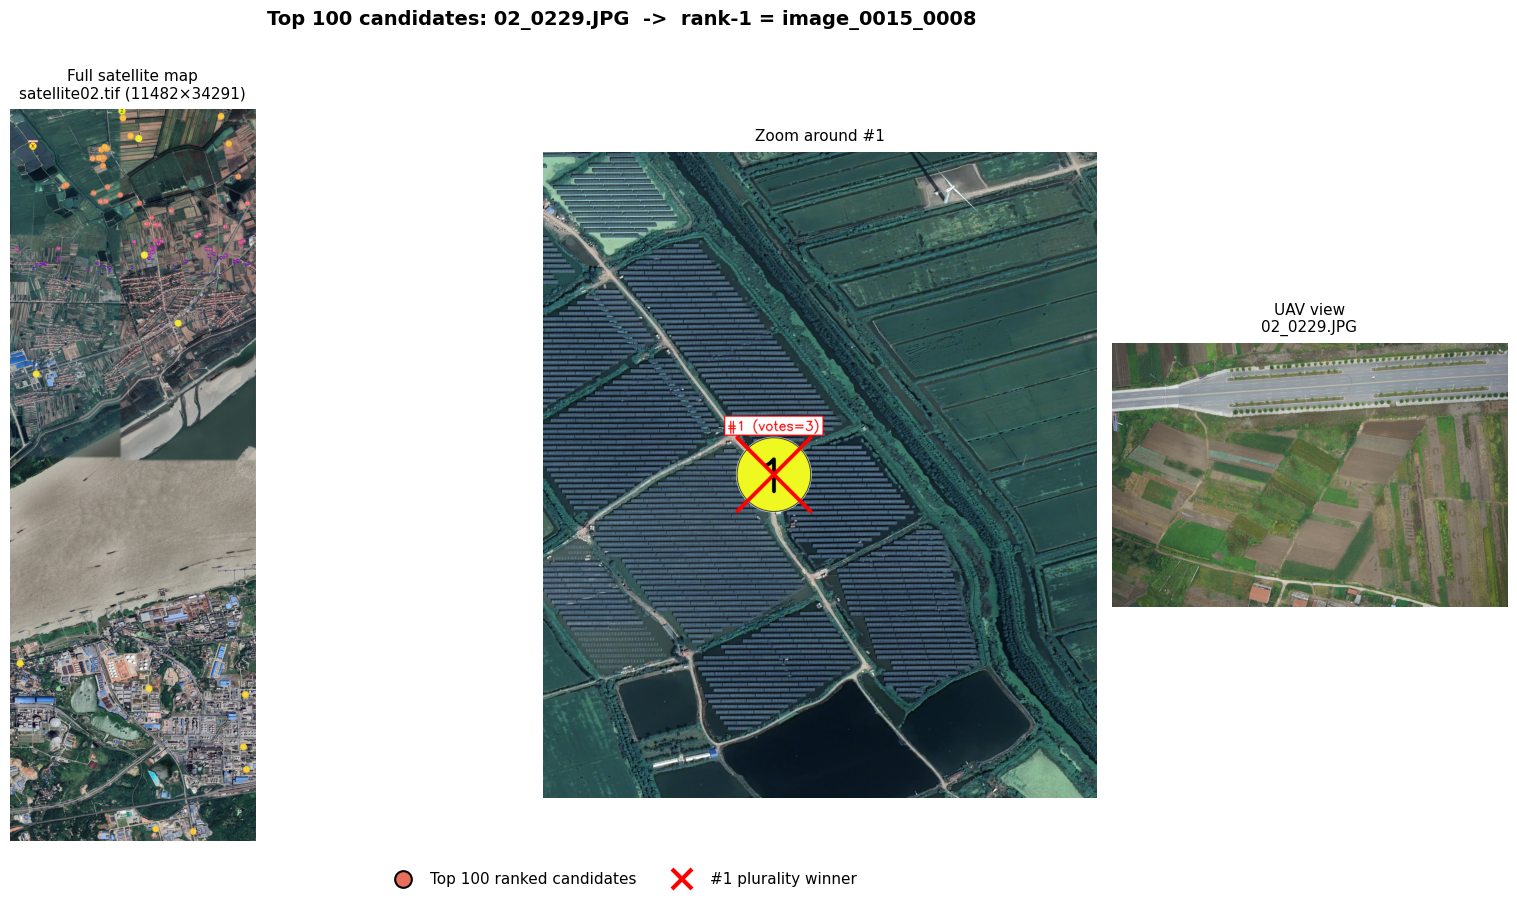

  Figure saved to: /home/nguyenduytan/LocalizationUAV/outputs/02/match_top100_02_0229.png


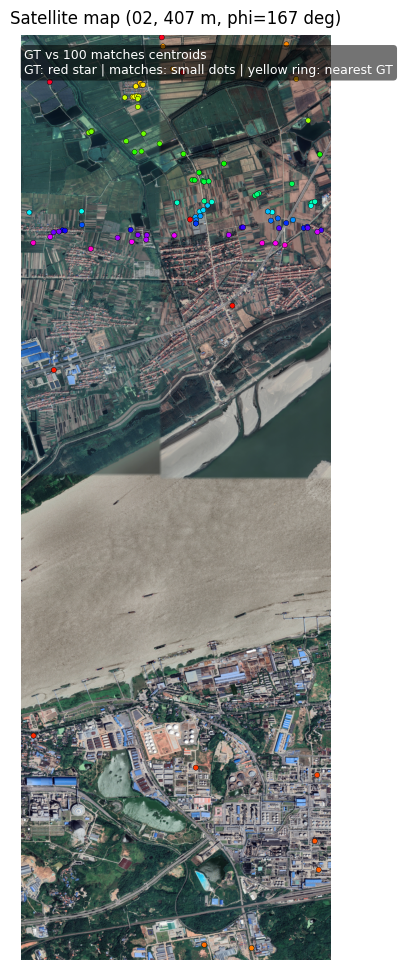

  GT-vs-top-N map saved to: /home/nguyenduytan/LocalizationUAV/outputs/02/gt_vs_top100_02_0229.png
Processing: 02_0052.JPG
  Pose: yaw=171.8, height=405.4
  No buildings segmented; skipping this sample.
Processing: 02_0564.JPG
  Pose: yaw=3.6, height=406.5
  No buildings segmented; skipping this sample.
Processing: 02_0502.JPG
  Pose: yaw=168.8, height=405.9
  UAV descriptors: 182
  Rank-1 patch  : image_0022_0037  (votes=2, margin=0)


[ WARN:0@315.050] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@315.050] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@315.050] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@315.050] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34736 (0x87b0) encountered
[ WARN:0@315.050] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered


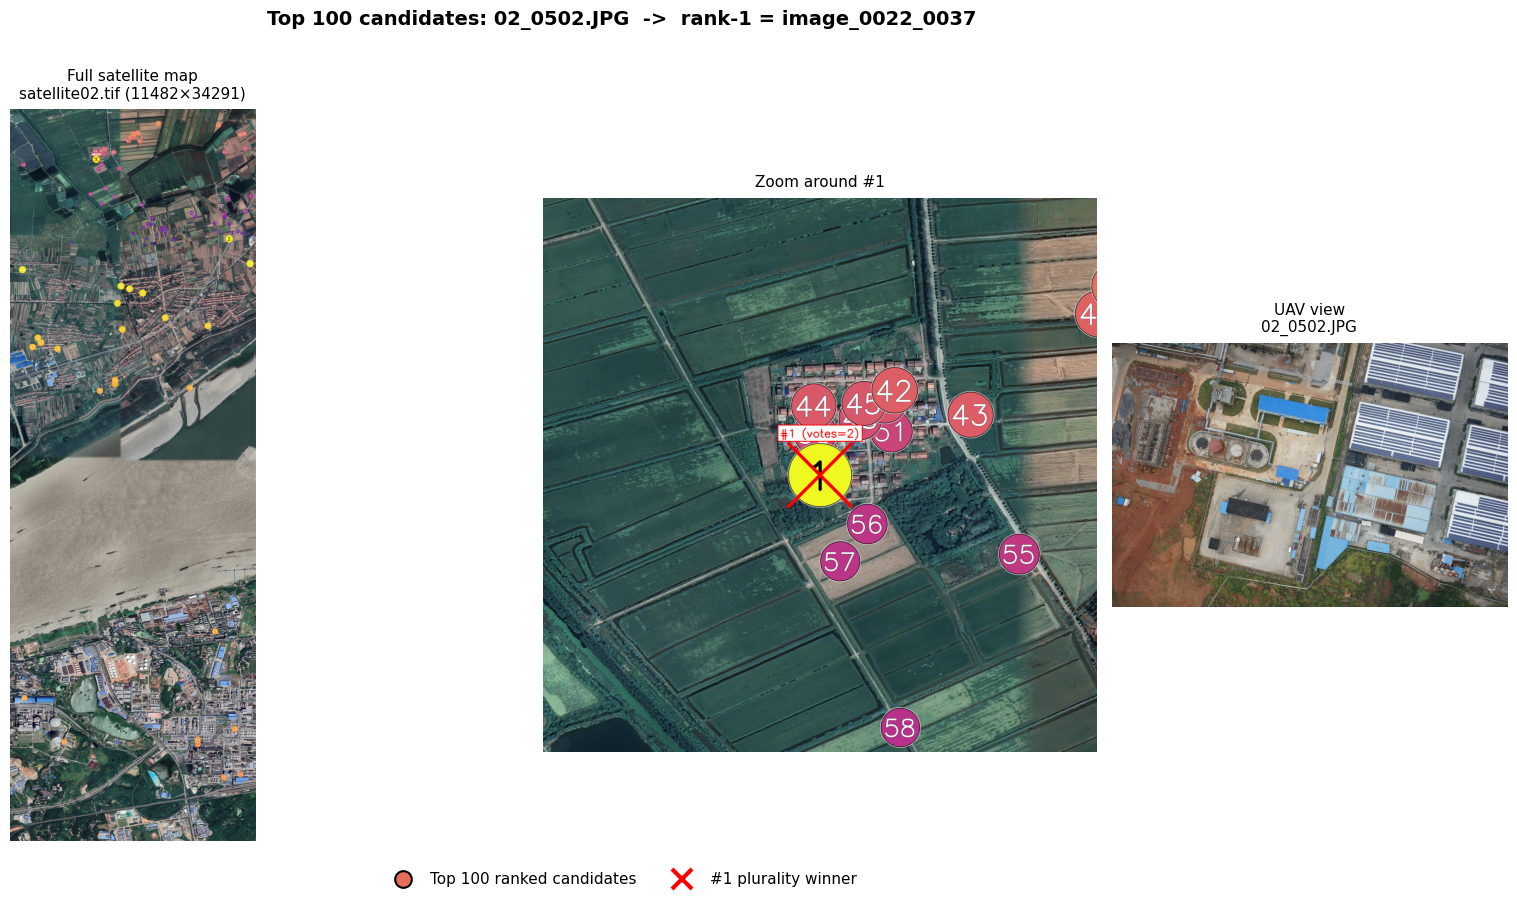

  Figure saved to: /home/nguyenduytan/LocalizationUAV/outputs/02/match_top100_02_0502.png


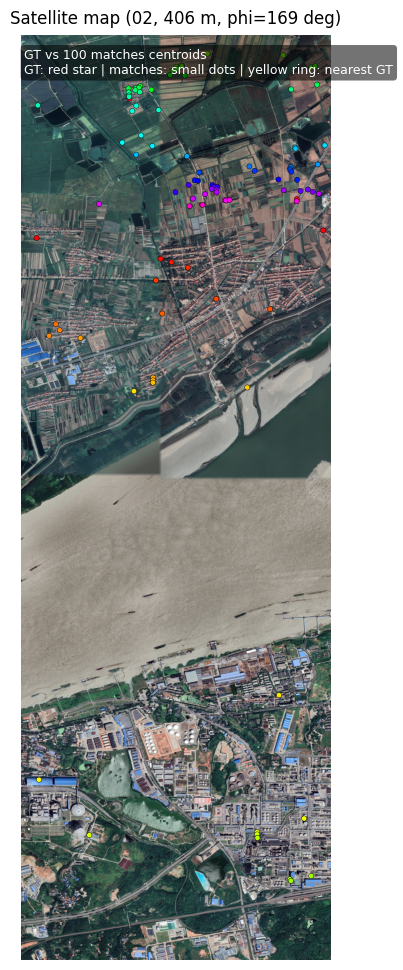

  GT-vs-top-N map saved to: /home/nguyenduytan/LocalizationUAV/outputs/02/gt_vs_top100_02_0502.png
Processing: 02_0458.JPG
  Pose: yaw=172.9, height=406.6
  No buildings segmented; skipping this sample.
All samples processed.


In [24]:
import matplotlib.pyplot as plt

results_summary = []

for sample_path in samples:
    image_name = sample_path.name
    print('=' * 70)
    print('Processing:', image_name)

    # Step 1: preprocess to 500x500
    _, img_uav_500, meta = process_uav(
        img_path=str(sample_path),
        csv_path=str(flight.metadata_csv),
    )
    print(f'  Pose: yaw={meta["Yaw (Phi)"]:.1f}, height={meta["height"]:.1f}')

    # Steps 2-4: descriptors
    uav_descriptors, _ = extract_patch_descriptors(
        patch_image=img_uav_500,
        model=model,
        device=device,
        score_threshold=0.5,
    )
    if uav_descriptors.shape[0] == 0:
        print('  No buildings segmented; skipping this sample.')
        results_summary.append({'image': image_name, 'descriptors': 0, 'error_m': None,
                               'rank1_patch': None, 'rank1_votes': None, 'margin': None})
        continue
    print(f'  UAV descriptors: {uav_descriptors.shape[0]}')

    # Step 5: KD-tree query + plurality vote + top-N list
    result = query_uav(uav_descriptors, db, k=TOP_K, top_n=TOP_N_TO_SHOW)
    if result is None:
        print('  Query produced no winner; skipping.')
        continue
    print(f'  Rank-1 patch  : {result.patch_id}  (votes={result.vote_count}, margin={result.margin})')

    # GT lookup + error in meters
    gt_pixel = None
    error_distance_m = None
    row = get_image_pose(metadata_df, image_name)
    if row is not None and bounds is not None:
        gt_lat, gt_lon = float(row['lat']), float(row['lon'])
        gt_pixel = latlon_to_pixel(gt_lat, gt_lon, bounds, sat_w, sat_h)
        offset = pixel_offset_to_meters(
            result.pixel_xy[0] - gt_pixel[0],
            result.pixel_xy[1] - gt_pixel[1],
            bounds, sat_w, sat_h,
        )
        error_distance_m = float(offset['distance_m'])
        print(f'  GT pixel      : {gt_pixel}')
        print(f'  Error vs GT   : {error_distance_m:.1f} m '
              f'(dx={offset["dx_m"]:.1f}, dy={offset["dy_m"]:.1f})')

    # Visualize top-N (3-panel)
    out_path = OUTPUT_DIR / f'match_top{TOP_N_TO_SHOW}_{sample_path.stem}.png'
    title = f'Top {TOP_N_TO_SHOW} candidates: {image_name}  ->  rank-1 = {result.patch_id}'
    if error_distance_m is not None:
        title += f'   (error: {error_distance_m:.1f} m)'

    fig = render_top_n_result(
        uav_image_path=str(sample_path),
        satellite_image_path=str(flight.satellite_tif),
        top_n=result.top_n,
        gt_pixel_xy=gt_pixel,
        error_distance_m=error_distance_m,
        zoom_radius_px=1500,
        highlight_top_k=5,
        title=title,
        output_path=str(out_path),
    )
    plt.show()
    plt.close(fig)
    print('  Figure saved to:', out_path)

    # Paper Fig. 5(a)-style "GT vs top-N matches centroids" map.
    fig5a_title = (
        f'Satellite map ({FLIGHT_ID}, {meta["height"]:.0f} m, '
        f'phi={meta["Yaw (Phi)"]:.0f} deg)'
    )
    gt_vs_top_path = OUTPUT_DIR / f'gt_vs_top{TOP_N_TO_SHOW}_{sample_path.stem}.png'
    fig5a = draw_gt_vs_topn_centroids(
        satellite_image_path=str(flight.satellite_tif),
        top_n=result.top_n,
        gt_pixel_xy=gt_pixel,
        title=fig5a_title,
        output_path=str(gt_vs_top_path),
    )
    plt.show()
    plt.close(fig5a)
    print('  GT-vs-top-N map saved to:', gt_vs_top_path)

    results_summary.append({
        'image': image_name,
        'descriptors': int(uav_descriptors.shape[0]),
        'rank1_patch': result.patch_id,
        'rank1_votes': int(result.vote_count),
        'margin': int(result.margin),
        'error_m': error_distance_m,
    })

print('=' * 70)
print('All samples processed.')


## 11. Summary table

In [25]:
summary_df = pd.DataFrame(results_summary)
summary_df


,image,descriptors,rank1_patch,rank1_votes,margin,error_m
0,02_0229.JPG,119,image_0015_0008,3.0,1.0,None
1,02_0052.JPG,0,None,NaN,NaN,None
2,02_0564.JPG,0,None,NaN,NaN,None
3,02_0502.JPG,182,image_0022_0037,2.0,0.0,None
4,02_0458.JPG,0,None,NaN,NaN,None


In [26]:
ok = summary_df['error_m'].notna()
if ok.any():
    print('Error vs GT (m) over', int(ok.sum()), 'samples:')
    print('  mean   :', float(summary_df.loc[ok, 'error_m'].mean()))
    print('  median :', float(summary_df.loc[ok, 'error_m'].median()))
    print('  min    :', float(summary_df.loc[ok, 'error_m'].min()))
    print('  max    :', float(summary_df.loc[ok, 'error_m'].max()))


Done. Per-image figures live in `outputs/01/match_top100_*.png` for inspection.